In [7]:
import numpy as np




In [28]:
x=np.array([2])
w=np.array([3])
y=x**2
y+=1






x

array([2])

In [9]:
d1 = {1: 1, 2: 2}
d2 = {4: 'ha!', 3: 3}
d1['d2'] = d2
d1


{1: 1, 2: 2, 'd2': {4: 'ha!', 3: 3}}

In [10]:
import torch
t=torch.tensor([[2,2,4],[1,1,9]])
t=t.unsqueeze(2)
t=t.unsqueeze(3)
t=t.repeat((1,1,3,3))
t.shape

torch.Size([2, 3, 3, 3])

In [11]:
t=torch.tensor([[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0],[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0]])

In [12]:
t

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0]])

In [13]:
x=t[:,0]==1
i=x.nonzero().squeeze().tolist()
i


[0, 6, 8, 14]

In [14]:
m=t.shape[1]
L=[]
i=t.nonzero()
for j in range(m):
    l=i[i[:,1]==j][:,0].tolist()
    print(l)
    L.append(l)
print(L)


[0, 6, 8, 14]
[1, 3, 7, 9, 11, 15]
[2, 4, 5, 10, 12, 13]
[[0, 6, 8, 14], [1, 3, 7, 9, 11, 15], [2, 4, 5, 10, 12, 13]]


In [15]:
from numpy import linalg as LA
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

#all parents
P3=Pin+Pin2
P3[P3!=0]=1
print(P3)

pr=1/2


E=W**2
needs=E@P3
needs=np.sqrt((needs))
print(needs)
row_l2_norm = LA.norm(W[:,[0,1,3]], axis=1)
print(row_l2_norm)

total=needs.shape[0]*needs.shape[1]
keep=(1-pr)*total
aligned_keep=needs.shape[0]
misaligned_keep=keep-aligned_keep
misaligned_total=total-aligned_keep
apr=misaligned_keep/total
print(total,keep,aligned_keep,misaligned_keep,misaligned_total,apr)

c2=1-Pout
print("c2", c2)
res1=needs*c2
print("res1", res1)
t=torch.quantile(torch.from_numpy(res1), 1-apr).item()
print(t)
res1[res1>t]=1
res1[res1!=1]=0
print(res1)
res1=res1+Pout
print(res1)
mask=res1@np.transpose(P3)
mask[mask!=0]=1
print(mask)






[[1 0 1]
 [1 1 0]
 [0 1 1]
 [1 0 0]]
[[ 6.55743852  5.          5.        ]
 [10.          7.          9.21954446]
 [14.2126704  13.45362405 10.        ]
 [17.69180601 13.         12.        ]]
[ 6.55743852 10.         14.2126704  17.69180601]
12 6.0 4 2.0 8 0.16666666666666666
c2 [[1 0 1]
 [1 0 1]
 [1 1 0]
 [0 1 1]]
res1 [[ 6.55743852  0.          5.        ]
 [10.          0.          9.21954446]
 [14.2126704  13.45362405  0.        ]
 [ 0.         13.         12.        ]]
13.07560400784562
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 0.]
 [0. 0. 0.]]
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 1. 1.]
 [1. 0. 0.]]
[[0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 1. 1.]
 [1. 1. 0. 1.]]


In [16]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2))


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 7  0]
 [ 7  0]
 [ 0 19]
 [ 0 19]]
52


In [17]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=C
print(costs)

res2=needs@costs
print(res2)


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 0 19]
 [ 7  0]]
[[ 7 19]
 [ 0 19]
 [ 7 19]
 [ 7 19]]


In [18]:
import matplotlib.pyplot as plt
def ppp(f):
    # Create an array of x values
    x = np.linspace(0, 10, 1000)
    a=20
    # Calculate the PDF for each x value
    pdf = torch.tanh(torch.from_numpy(a*x)).numpy()

    # Plot the PDF
    plt.plot(x, pdf)
    plt.show()

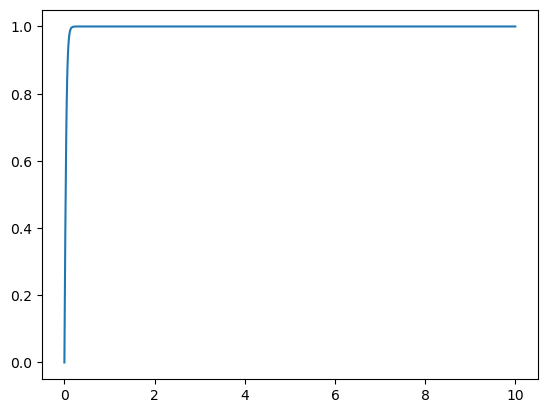

In [19]:
f=torch.tanh
ppp(f)

In [20]:
def softmax(x):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = np.exp((x - np.max(x))) # Subtracting np.max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [21]:
def pnormalize(x,p=2):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = x**p # Subtracting np.max(x) for numerical stability
    return e_x #/ e_x.sum(axis=0)

In [22]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[0.8,0.2],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0.2,0.8],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])


needs=E@Pin
print(needs)
#needs[needs!=0]=1
needs=pnormalize(needs)

print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2,axis=1))


[[2.6 1.4]
 [2.4 0.6]
 [1.8 1.2]
 [1.  1. ]]
[[6.76 1.96]
 [5.76 0.36]
 [3.24 1.44]
 [1.   1.  ]]
[[ 5.6  3.8]
 [ 5.6  3.8]
 [ 1.4 15.2]
 [ 1.4 15.2]]
[45.304 33.624 26.424 16.6  ]
